## EDA & ACCIONABLES - DATA GENERAL LEDGER ##



In [3]:
# ==============================================================================
# 1. CONFIGURACIÓN E IMPORTACIONES
# ==============================================================================
%matplotlib inline 
import pandas as pd
import os, logging
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Ignorar advertencias comunes de pandas o matplotlib para un output más limpio
warnings.filterwarnings('ignore') 
# Configuración de Matplotlib/Seaborn para mejor visualización
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Resolución de los gráficos

In [4]:
# Logging mínimo
logging.basicConfig(
    filename="../LOGS/08-eda_accionables_gl_p_l.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [5]:
# --- Variables de Configuración ---
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'
FINANCIAL_COLS = ['DEBIT', 'CREDIT', 'NET']
CATEGORY_COLS_FOR_VIS = ['ENTERPRISENAME', 'COANAME', 'DESCTYPE', 'LOCATION'] 
DATE_COL = 'MONTHID' 

# ==============================================================================
# 2. FUNCIONES DE ANÁLISIS
# ==============================================================================

def data_quality_check(df):
    """Realiza la verificación inicial de calidad de los datos (nulos, tipos, duplicados, rangos)."""
    print("="*80)
    print("--- 1. ANÁLISIS DE CALIDAD DE DATOS ---")
    print("="*80)
    
    # 1.1 Inspección Inicial
    print("\n1.1. Inspección Inicial (Primeras 5 Filas):")
    print(df.head())
    
    # 1.2 Tipos de Datos y Valores No Nulos
    print("\n" + "-"*50)
    print("1.2. Tipos de Datos y Conteo de No Nulos:")
    df.info()

    # 1.3 Valores Nulos (Missing Values)
    print("\n" + "-"*50)
    print("1.3. Conteo y Porcentaje de Valores Nulos:")
    missing_data = df.isnull().sum().sort_values(ascending=False)
    missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'Total Nulos': missing_data, 'Porcentaje (%)': missing_percentage})
    
    missing_df = missing_df[missing_df['Total Nulos'] > 0]
    if not missing_df.empty:
        print(missing_df)
    else:
        print("✅ No se encontraron valores nulos en el conjunto de datos.")

    # 1.4 Duplicados
    print("\n" + "-"*50)
    print("1.4. Duplicados:")
    n_duplicates = df.duplicated().sum()
    print(f"Número total de filas duplicadas: {n_duplicates}")
    
    # 1.5 Rangos y Outliers (Estadísticas Descriptivas y Box Plots)
    print("\n" + "-"*50)
    print("1.5. Rangos y Outliers (Estadísticas y Box Plots):")
    print("\nEstadísticas Descriptivas para Columnas Numéricas:")
    print(df.describe().T)
    
    # Generación de Box Plots
    for col in FINANCIAL_COLS:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            plt.figure(figsize=(10, 5))
            sns.boxplot(x=df[col])
            plt.title(f'Box Plot de {col} para Detección de Outliers')
            plt.xlabel(col)
            plt.tight_layout()
            plt.show() # Muestra la imagen

def distributions_and_relationships(df):
    """Analiza las distribuciones de variables clave y sus correlaciones."""
    print("\n" + "="*80)
    print("--- 2. DISTRIBUCIONES Y RELACIONES ---")
    print("="*80)

    # 2.1 Distribuciones (Histogramas)
    print("\n--- 2.1. Distribuciones (Histogramas de Columnas Financieras) ---")
    for col in FINANCIAL_COLS:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            plt.figure(figsize=(10, 6))
            # Se usa transformación logarítmica para manejar el sesgo financiero
            sns.histplot(df[col].apply(lambda x: np.log1p(abs(x)) * np.sign(x) if x != 0 else 0), kde=True, bins=50)
            plt.title(f'Distribución de {col} (Escala log-transformada)')
            plt.xlabel(f'{col} (log1p Transformación)')
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show() # Muestra la imagen
    
    # 2.2 Balance de Variables Categóricas (Top 10)
    print("\n--- 2.2. Balance de Variables Categóricas Clave (Top 10) ---")
    for col in CATEGORY_COLS_FOR_VIS:
        if col in df.columns:
            top_n = df[col].value_counts(dropna=False).head(10)
            plt.figure(figsize=(12, 6))
            sns.barplot(x=top_n.index.astype(str), y=top_n.values, palette='viridis')
            plt.title(f'Balance/Distribución de las 10 Principales Categorías en {col}')
            plt.xlabel(col)
            plt.ylabel('Conteo')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show() # Muestra la imagen
    
    # 2.3 Correlaciones (Heatmap)
    print("\n--- 2.3. Correlaciones (Matriz de Heatmap) ---")
    numerical_df = df.select_dtypes(include=np.number)
    correlation_matrix = numerical_df.corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, linecolor='black')
    plt.title('Matriz de Correlación de Variables Numéricas')
    plt.tight_layout()
    plt.show() # Muestra la imagen
    
    # 2.4 Tendencia de NET a lo largo del tiempo (Drift inicial)
    print("\n--- 2.4. Tendencia de NET a lo largo del tiempo ---")
    if 'YEARID' in df.columns and DATE_COL in df.columns and 'NET' in df.columns:
        try:
            df['PERIOD'] = df['YEARID'].astype(str) + '-' + df[DATE_COL].astype(str).str.zfill(2)
            monthly_net = df.groupby('PERIOD')['NET'].sum().sort_index()
            
            plt.figure(figsize=(14, 7))
            monthly_net.plot(kind='line', marker='o', color='darkblue')
            plt.title('Tendencia de NET Acumulado Mensual a lo largo del Período')
            plt.xlabel('Período (Año-Mes)')
            plt.ylabel('NET Acumulado Mensual')
            plt.xticks(rotation=45, ha='right')
            plt.grid(True, alpha=0.6)
            plt.tight_layout()
            plt.show() # Muestra la imagen
            
        except Exception as e:
            print(f"Advertencia: No se pudo generar el gráfico de tendencia. Error: {e}")

def discuss_risks():
    """Discusión conceptual sobre los riesgos (Desbalance, Leakage, Drift, Sesgos)."""
    print("\n" + "="*80)
    print("--- 3. RIESGOS (Análisis Conceptual Post-EDA) ---")
    print("="*80)
    print("\n3.1. Desbalance (Imbalance):")
    print("   - **Identificación:** Se observa en los gráficos de balance (Sección 2.2). Un desbalance alto en categorías clave sesgará cualquier análisis predictivo.")
    print("   - **Acción:** Consolidar categorías minoritarias o aplicar técnicas de submuestreo/sobremuestreo para ML.")
    print("\n3.2. Leakage (Fuga de Información):")
    print("   - **Potencial:** Columnas de identificadores únicos (`LIBDIARIOID`, IDs) o variables que son el resultado del evento que se quiere predecir. Son 'atajos' que no generalizan.")
    print("   - **Acción:** Excluir columnas ID y variables de 'estado final' de los *features* de un modelo predictivo.")
    print("\n3.3. Drift (Deriva):")
    print("   - **Identificación:** Cambios significativos en la media, volatilidad o distribución de `NET` a lo largo del tiempo (Sección 2.4).")
    print("   - **Acción:** Monitorear el rendimiento de modelos por período y reentrenar ante cambios abruptos.")
    print("\n3.4. Sesgos (Biases):")
    print("   - **Potencial:** Sesgo de muestreo (si el archivo no representa todas las entidades/estados) o sesgo de medición (si una columna no registra lo que se espera).")
    print("   - **Acción:** Validar la representatividad de los datos con el equipo de negocio antes de generalizar conclusiones.")

def actionable_conclusions():
    """Resumen de las conclusiones y recomendaciones de limpieza/Feature Engineering."""
    print("\n" + "="*80)
    print("--- 4. CONCLUSIONES ACCIONABLES ---")
    print("="*80)
    print("\n4.1. Recomendaciones de Limpieza:")
    print("   - **Nulos:** Imputar o eliminar filas/columnas según el porcentaje de nulos y la importancia de la columna (ej. imputar mediana para `CAPRATE` si el porcentaje es bajo).")
    print("   - **Outliers:** Investigar los outliers en `DEBIT`/`CREDIT`/`NET` (vistos en los Box Plots) para determinar si son errores de registro o transacciones legítimas de alto valor.")
    print("\n4.2. Ingeniería de Características (Feature Engineering):")
    print("   - **Fecha/Tiempo:** Crear un objeto `datetime` a partir de `YEARID` y `MONTHID` para extraer características temporales (trimestre, día de la semana).")
    print("   - **Cuentas Contables:** Reducir la cardinalidad de `COACODDETAIL` agrupando por los niveles superiores del Plan de Cuentas (ej. los primeros 2 o 3 dígitos).")
    print("\n4.3. Foco del Análisis de Negocio:")
    print("   - **Segmentación:** Utilizar las dimensiones `ENTERPRISENAME` y `LOCATION` para segmentar el análisis de rendimiento financiero (`NET`) y entender las diferencias operacionales.")

# ==============================================================================
# 3. FUNCIÓN PRINCIPAL Y EJECUCIÓN
# ==============================================================================

def run_eda(file_path):
    """Función principal para cargar los datos y ejecutar todas las etapas del EDA."""
    try:
        # Intenta cargar el archivo (usando latin1 como alternativa si falla por codificación)
        try:
            df = pd.read_csv(file_path)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding='latin1')
        except FileNotFoundError:
            print(f"❌ Error: El archivo '{file_path}' no fue encontrado. Asegúrate de que está en el directorio correcto.")
            return

        print(f"✅ Archivo '{file_path}' cargado exitosamente. Total de filas: {len(df)}")
        
        data_quality_check(df.copy()) 
        distributions_and_relationships(df.copy())
        discuss_risks()
        actionable_conclusions()
        
        print("\n" + "="*80)
        print("🎉 EDA Completo. Todos los gráficos se han mostrado en las celdas de output.")
        print("==================================================================================")
        
    except Exception as e:
        print(f"❌ Ocurrió un error inesperado durante la ejecución del EDA: {e}")



✅ Archivo '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv' cargado exitosamente. Total de filas: 293974
--- 1. ANÁLISIS DE CALIDAD DE DATOS ---

1.1. Inspección Inicial (Primeras 5 Filas):
   LIBDIARIOID  ENTERPRISEID ENTEPRISENAME  PROPERTYID  LIBDIATYPEID  YEARID  \
0            1             2   Entity_0002          85             2    2020   
1            1             2   Entity_0002          85             2    2020   
2            2             3   Entity_0003          87             2    2020   
3            2             3   Entity_0003          87             2    2020   
4            3             7   Entity_0007         102             2    2020   

   MONTHID  SOURCEID  ODATAID  COACODDETAIL  ... CAPRATE TENANTID  \
0        1         2        3        101001  ...   8.375      3.0   
1        1         2        3        700101  ...   8.375      3.0   
2        1         2        3        101001  ...   8.420      3.0   
3        1         2        3        700101  ...   8.420 

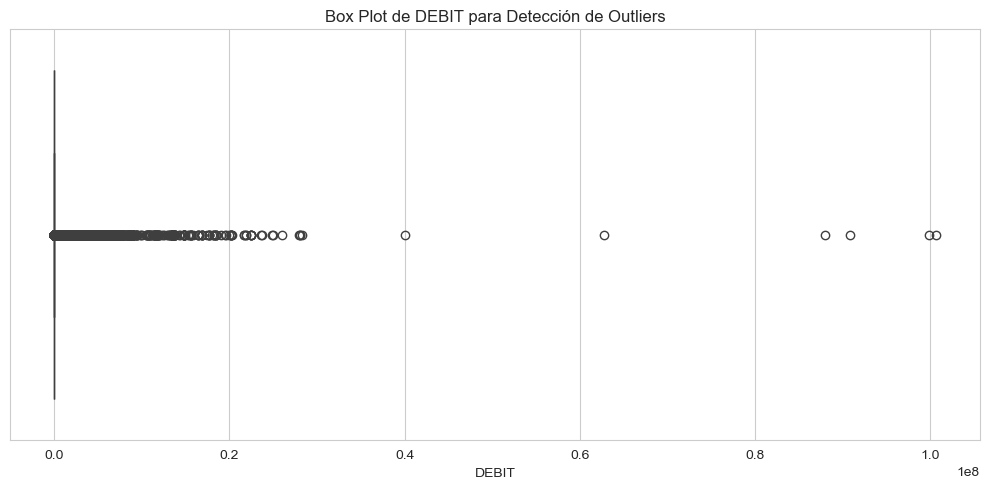

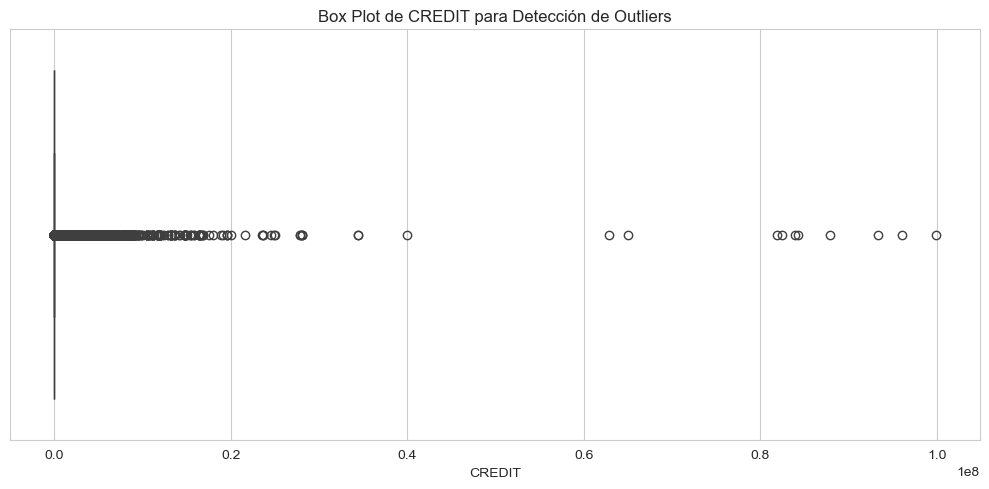

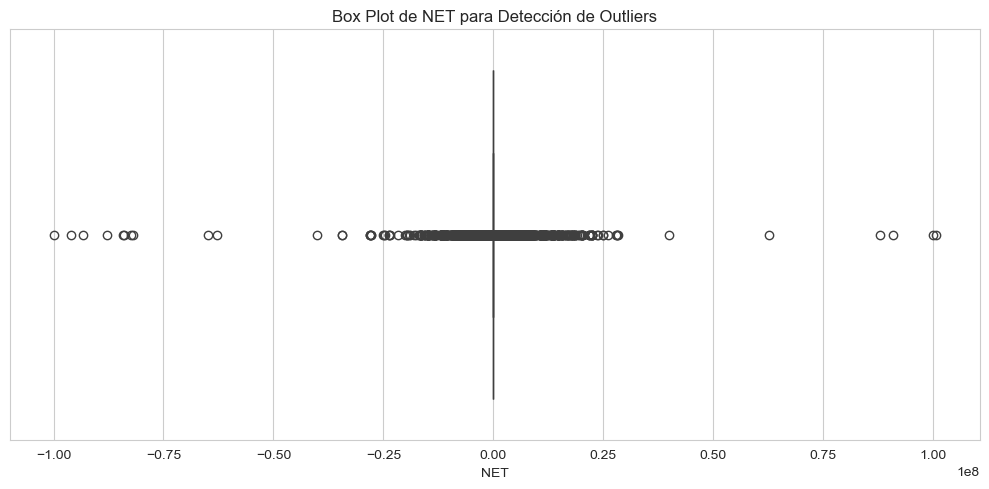


--- 2. DISTRIBUCIONES Y RELACIONES ---

--- 2.1. Distribuciones (Histogramas de Columnas Financieras) ---


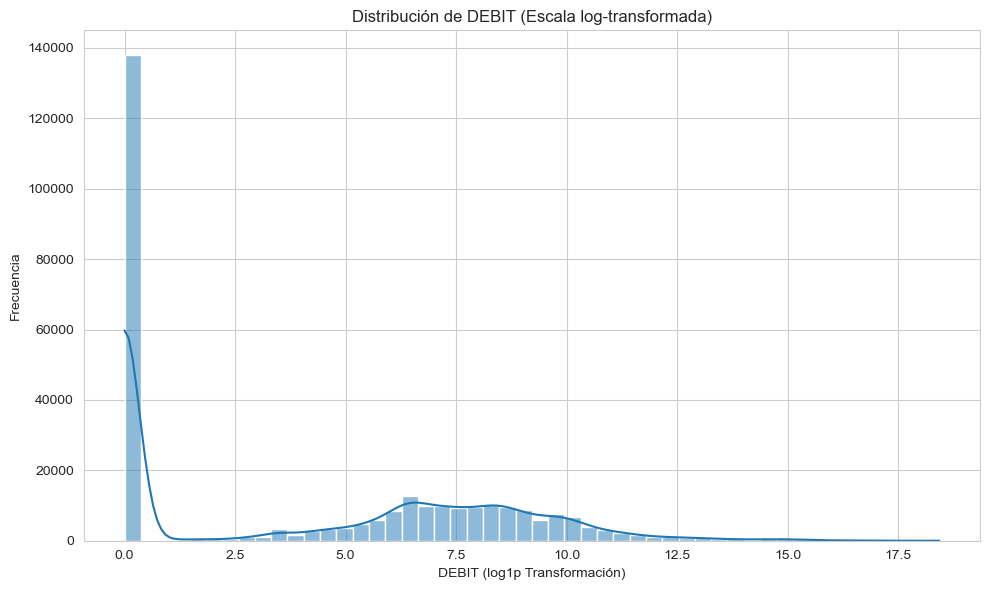

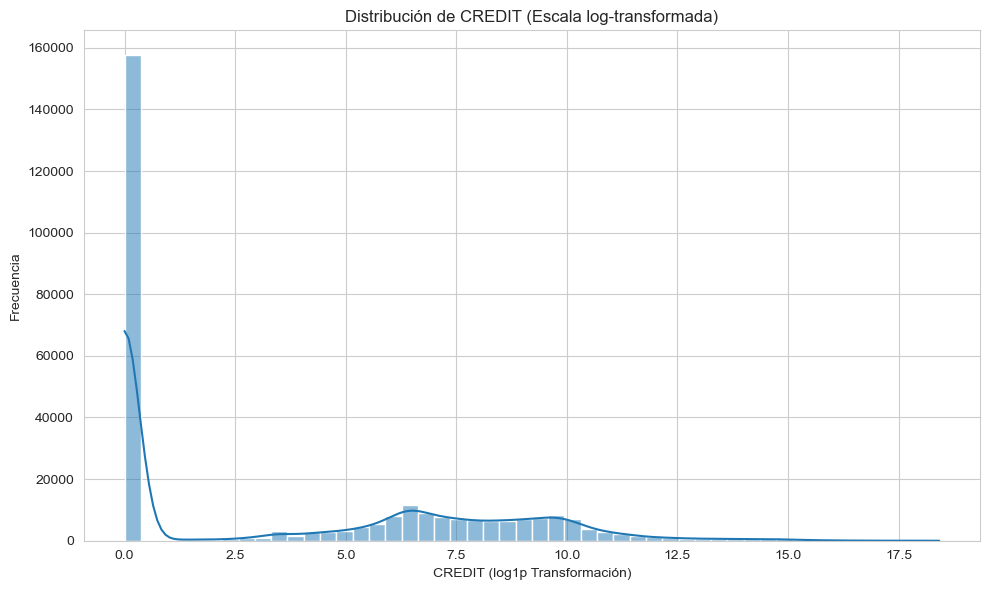

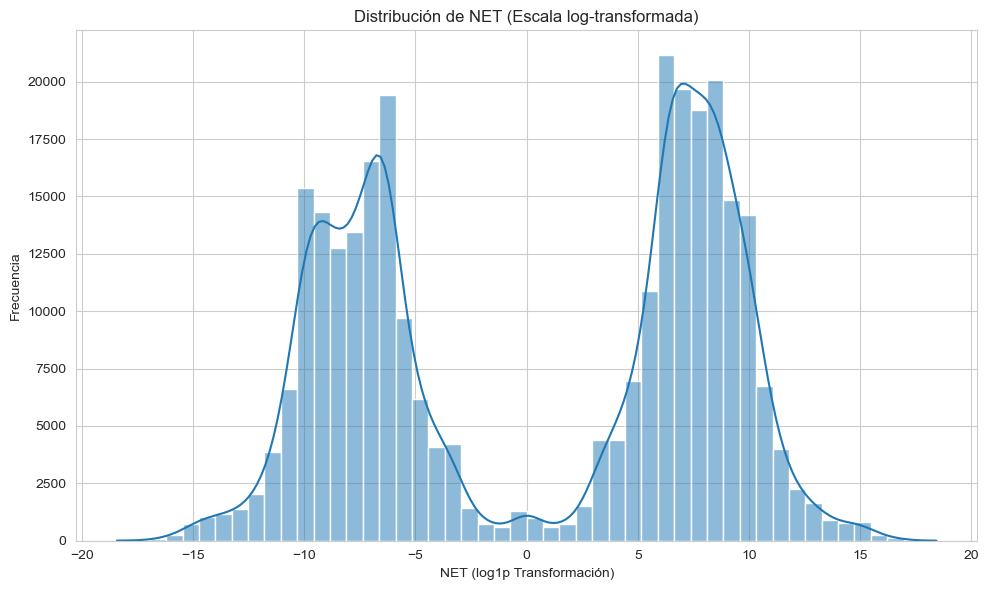


--- 2.2. Balance de Variables Categóricas Clave (Top 10) ---


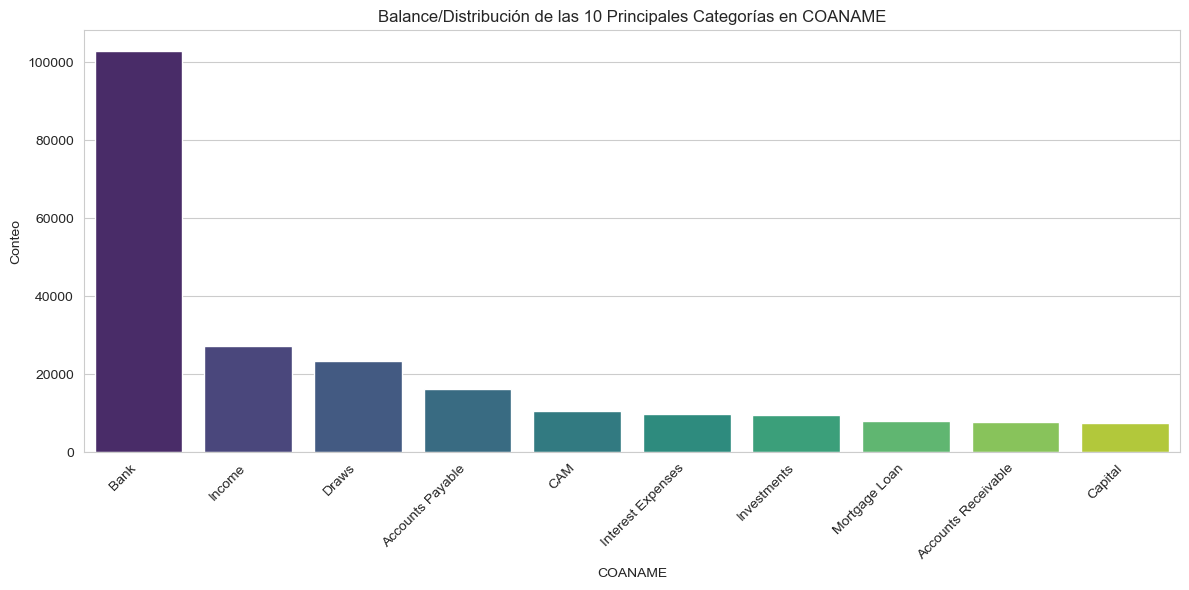

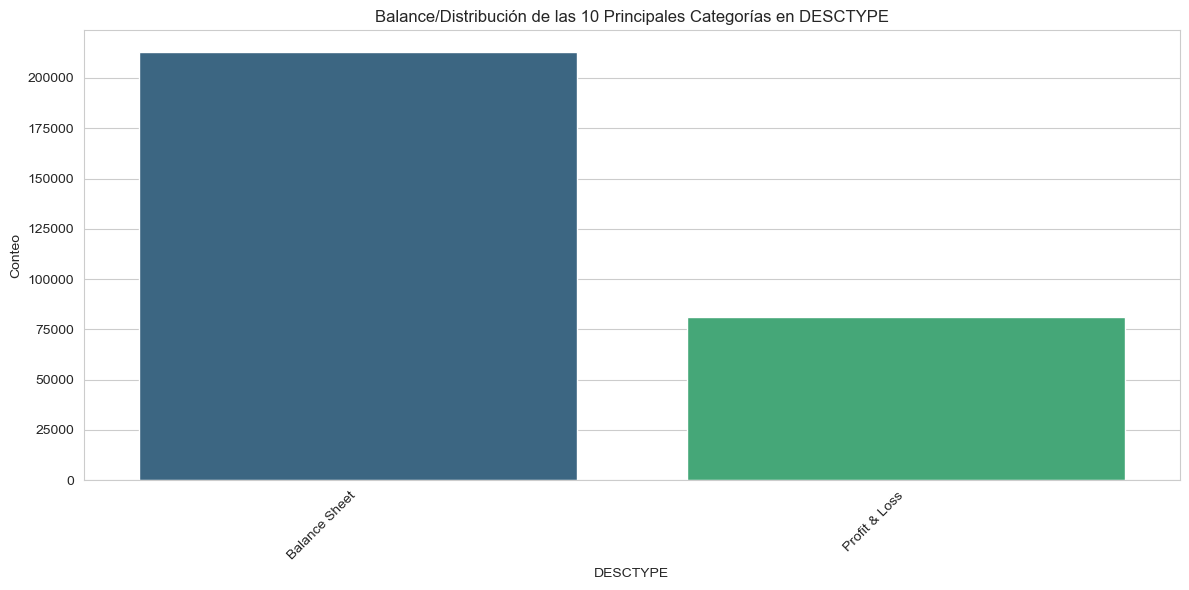

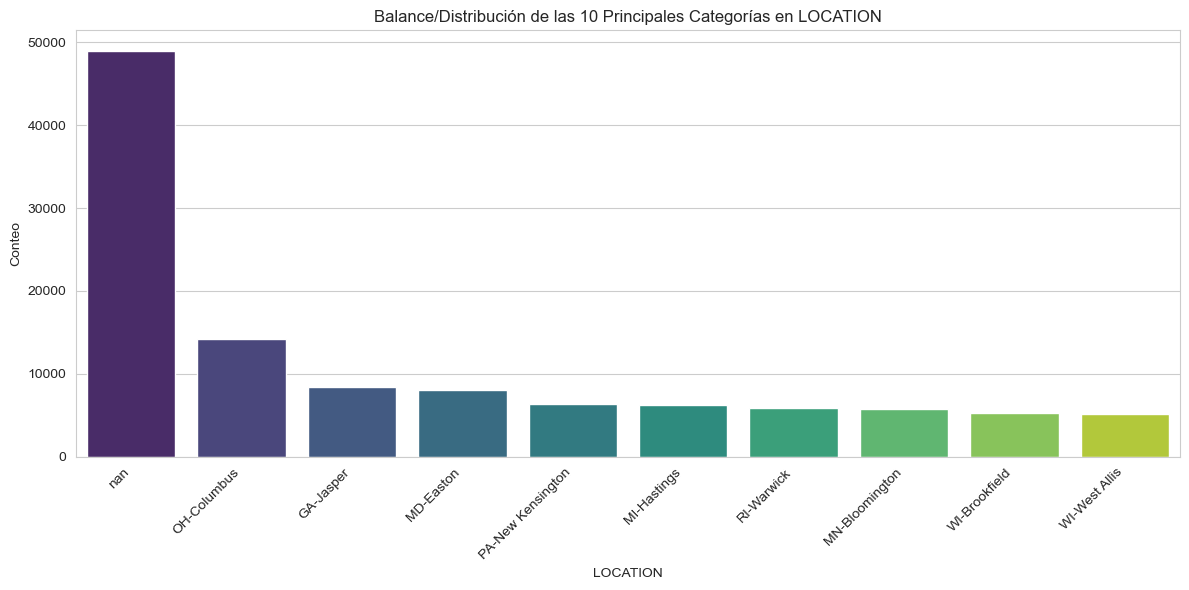


--- 2.3. Correlaciones (Matriz de Heatmap) ---


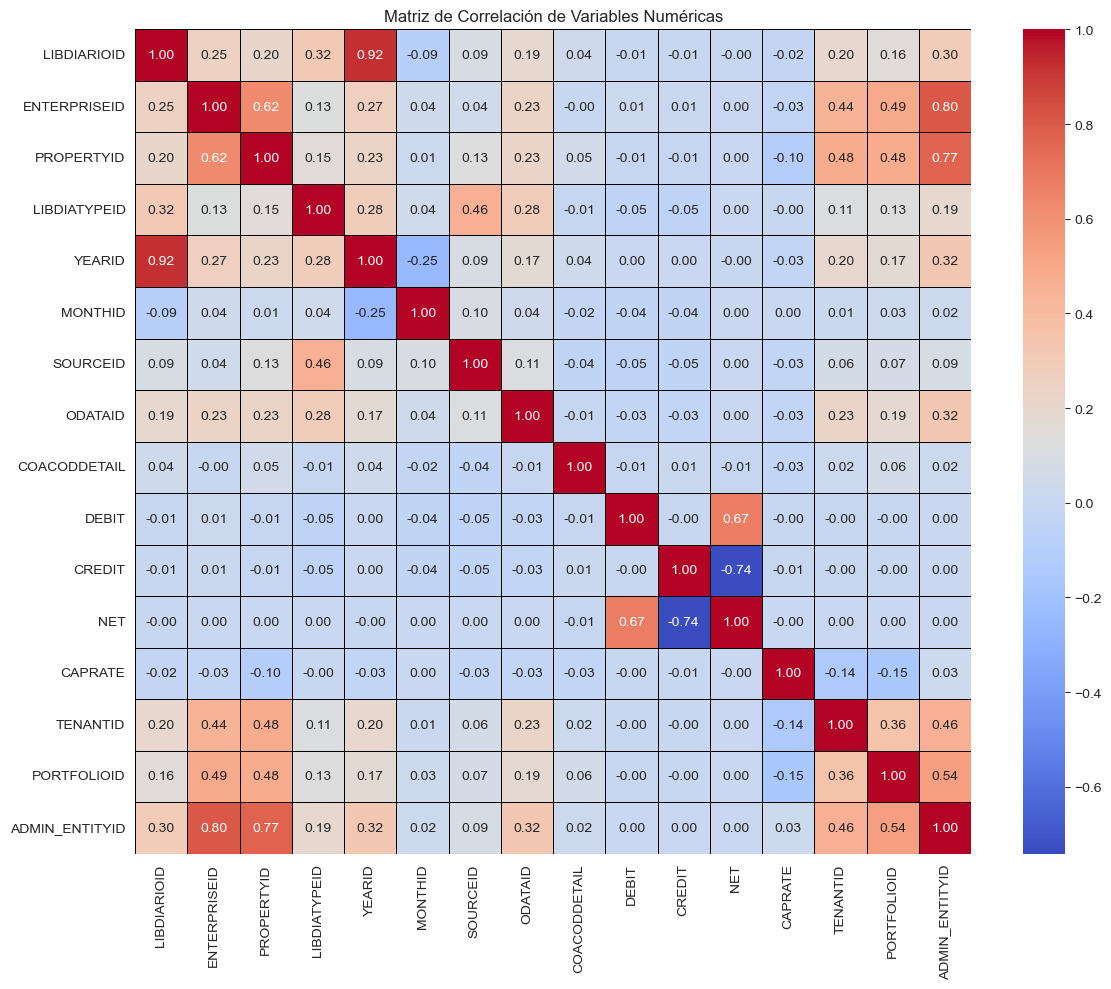


--- 2.4. Tendencia de NET a lo largo del tiempo ---


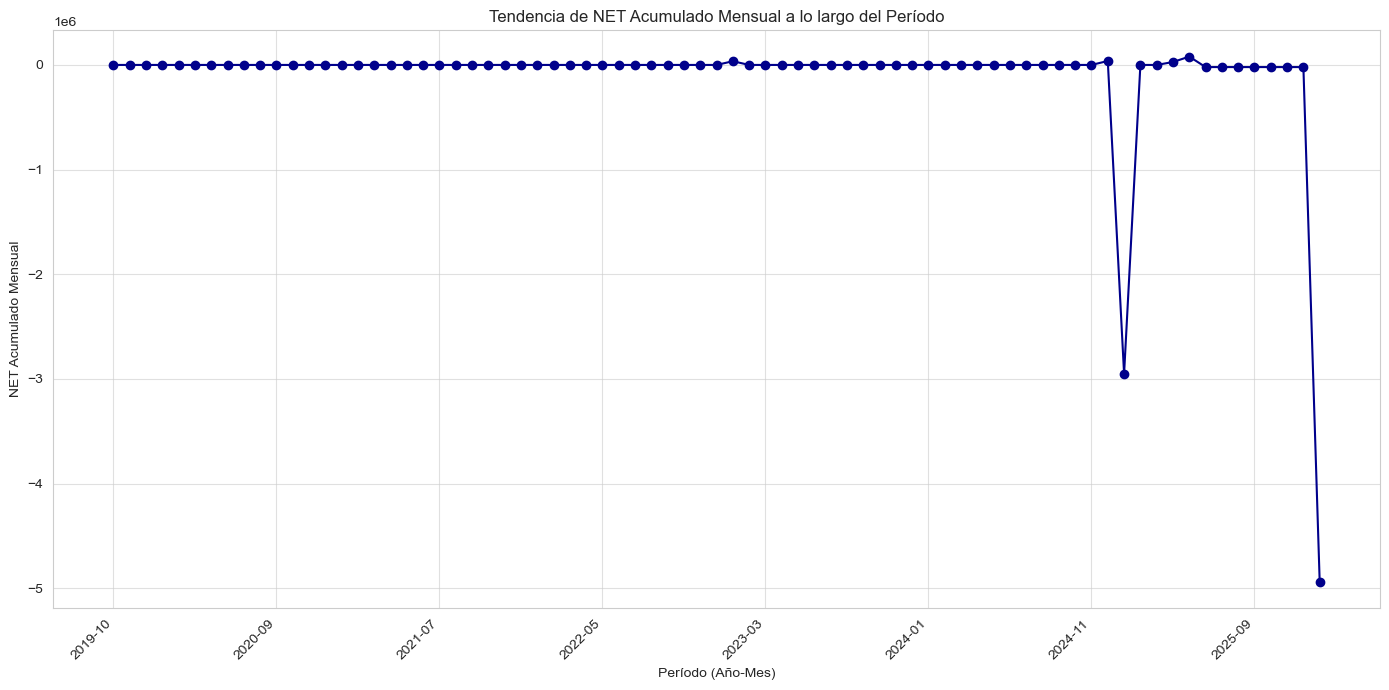


--- 3. RIESGOS (Análisis Conceptual Post-EDA) ---

3.1. Desbalance (Imbalance):
   - **Identificación:** Se observa en los gráficos de balance (Sección 2.2). Un desbalance alto en categorías clave sesgará cualquier análisis predictivo.
   - **Acción:** Consolidar categorías minoritarias o aplicar técnicas de submuestreo/sobremuestreo para ML.

3.2. Leakage (Fuga de Información):
   - **Potencial:** Columnas de identificadores únicos (`LIBDIARIOID`, IDs) o variables que son el resultado del evento que se quiere predecir. Son 'atajos' que no generalizan.
   - **Acción:** Excluir columnas ID y variables de 'estado final' de los *features* de un modelo predictivo.

3.3. Drift (Deriva):
   - **Identificación:** Cambios significativos en la media, volatilidad o distribución de `NET` a lo largo del tiempo (Sección 2.4).
   - **Acción:** Monitorear el rendimiento de modelos por período y reentrenar ante cambios abruptos.

3.4. Sesgos (Biases):
   - **Potencial:** Sesgo de muestreo (si el arch

In [6]:
# --- EJECUCIÓN ---
run_eda('../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv')

## 1. Limpieza de Datos  ##

Contiene las funciones para la limpieza de nulos y el tratamiento de outliers.

In [15]:
import pandas as pd
import numpy as np
import warnings

# Ignorar advertencias de pandas (útil en entornos de notebook/colab)
warnings.filterwarnings('ignore')

# Ruta del archivo real a cargar
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'

# ==============================================================================
# 4.1. RECOMENDACIONES DE LIMPIEZA
# ==============================================================================

def handle_missing_values(df, caprate_col='CAPRATE'):
    """
    Recomendación 4.1. Nulos:
    Imputa valores nulos de CAPRATE con la mediana.
    Las columnas de IDs categóricos con nulos se imputan con 'SIN_VALOR'.
    """
    print("--- Limpieza de Valores Nulos ---")
    
    # 1. Imputar CAPRATE (Numérico) con la mediana
    if caprate_col in df.columns and df[caprate_col].isnull().any():
        median_caprate = df[caprate_col].median()
        df.loc[:, caprate_col] = df[caprate_col].fillna(median_caprate)
        print(f"✅ Columna '{caprate_col}' imputada con la mediana: {median_caprate:.4f}")
    
    # 2. Imputar nulos en columnas categóricas importantes con 'SIN_VALOR'
    categorical_cols_to_fill = ['TENANTID', 'TENANTNAME', 'OPT_LEASE', 'MJ_OWNER']
    for col in categorical_cols_to_fill:
        if col in df.columns and df[col].isnull().any():
            df.loc[:, col] = df[col].fillna('SIN_VALOR')
            print(f"✅ Columna '{col}' rellenada con 'SIN_VALOR'.")
            
    return df

def detect_outliers_iqr(df, cols=['DEBIT', 'CREDIT', 'NET']):
    """
    Recomendación 4.1. Outliers:
    Calcula los límites IQR (Rango Intercuartílico) para detectar outliers
    en las columnas financieras y retorna un resumen, sin modificarlos.
    """
    print("\n--- Detección de Outliers (Límites IQR) ---")
    outlier_summary = {}

    for col in cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Contar outliers
            outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            
            outlier_summary[col] = {
                'Q1': Q1,
                'Q3': Q3,
                'Límite Inferior': lower_bound,
                'Límite Superior': upper_bound,
                'Total Outliers': outliers_count
            }
            print(f"🔎 {col}: {outliers_count:,} outliers detectados (Límite Sup: {upper_bound:,.2f})")

    # Retorna el DataFrame original y el resumen de outliers
    return df, outlier_summary


# ==============================================================================
# 4.2. INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

def create_time_features(df, year_col='YEARID', month_col='MONTHID'):
    """
    Recomendación 4.2. Fecha/Tiempo:
    Crea un objeto datetime a partir de YEARID y MONTHID para extraer características temporales.
    """
    print("\n--- Creación de Características de Tiempo ---")
    
    # 1. Convertir a enteros y formatear
    df.loc[:, year_col] = df[year_col].fillna(0).astype(int).astype(str)
    df.loc[:, month_col] = df[month_col].fillna(0).astype(int).astype(str).str.zfill(2)
    
    # 2. Crear una fecha y manejar errores
    date_series = pd.to_datetime(df[year_col] + '-' + df[month_col] + '-01', errors='coerce')
    
    # Eliminar filas donde la fecha no pudo ser parseada
    df = df[date_series.notna()].copy()
    df.loc[:, 'TRANSACTION_DATE'] = date_series
    
    # 3. Extraer características
    df.loc[:, 'TR_QUARTER'] = df['TRANSACTION_DATE'].dt.quarter
    df.loc[:, 'TR_MONTH_NAME'] = df['TRANSACTION_DATE'].dt.strftime('%B')
    df.loc[:, 'TR_DAY_OF_WEEK'] = df['TRANSACTION_DATE'].dt.day_name()
    
    print("✅ Características de fecha (TRANSACTION_DATE, TR_QUARTER, TR_MONTH_NAME, TR_DAY_OF_WEEK) creadas.")
    
    return df

def reduce_coa_cardinality(df, coa_col='COACODDETAIL', level=3):
    """
    Recomendación 4.2. Cuentas Contables:
    Reduce la cardinalidad de COACODDETAIL agrupando por el nivel N (ej. los primeros 3 dígitos).
    """
    print(f"\n--- Reducción de Cardinalidad de '{coa_col}' (Nivel {level}) ---")
    
    if coa_col not in df.columns:
        print(f"❌ Advertencia: La columna '{coa_col}' no se encuentra en el DataFrame. Omitiendo reducción de cardinalidad.")
        return df
        
    initial_unique = df[coa_col].astype(str).nunique()
    
    # Asegurarse de que el código sea string y rellenar con ceros
    df.loc[:, 'COA_LEVEL'] = df[coa_col].astype(str).str.zfill(10).str[:level] 
    
    final_unique = df['COA_LEVEL'].nunique()
    
    print(f"✅ Cardinalidad reducida de {initial_unique} a {final_unique} grupos ({level} dígitos).")
    
    return df

# ==============================================================================
# FUNCIÓN PRINCIPAL DE EJECUCIÓN
# ==============================================================================

if __name__ == '__main__':
    
    try:
        # Cargar el DataFrame real
        df_full = pd.read_csv(FILE_PATH, encoding='latin1')
        df_full.columns = df_full.columns.str.strip() # Limpiar nombres de columnas
        
        print(f"✅ Archivo '{FILE_PATH}' cargado exitosamente. Filas iniciales: {len(df_full)}")

        # --- FASE 1: LIMPIEZA DE DATOS (4.1) ---
        df_cleaned = handle_missing_values(df_full.copy())
        
        # Detección de Outliers (no se eliminan, solo se analiza el resumen)
        df_cleaned, outlier_summary = detect_outliers_iqr(df_cleaned)
        
        # --- FASE 2: FEATURE ENGINEERING (4.2) ---
        
        # 1. Características de Tiempo
        df_processed = create_time_features(df_cleaned.copy())

        # 2. Reducción de Cardinalidad de Cuentas Contables (COA)
        # Usamos level=3 como ejemplo (los primeros 3 dígitos del COA)
        df_final = reduce_coa_cardinality(df_processed.copy(), level=3)

        print("\n" + "="*80)
        print("MUESTRA DEL DATAFRAME PROCESADO (FLUIDO DE LIMPIEZA Y FEAT. ENG.)")
        print("==================================================================================")
        
        # Mostrar las columnas transformadas junto a algunas originales
        sample_cols = ['CAPRATE', 'TENANTID', 'TRANSACTION_DATE', 'TR_QUARTER', 
                       'COACODDETAIL', 'COA_LEVEL', 'DEBIT', 'CREDIT', 'NET']
                       
        cols_to_display = [col for col in sample_cols if col in df_final.columns]
        
        if not df_final.empty:
            print(df_final[cols_to_display].head())
        else:
            print("El DataFrame resultante está vacío después de la limpieza de fechas inválidas.")
            
        print("..." * 20)
        print(f"Dimensiones finales del DataFrame: {df_final.shape}")

    except FileNotFoundError:
        print(f"❌ Error: El archivo '{FILE_PATH}' no fue encontrado. Asegúrate de que la ruta es correcta.")
    except Exception as e:
        print(f"❌ Ocurrió un error inesperado al procesar el archivo: {type(e).__name__}: {e}")

✅ Archivo '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv' cargado exitosamente. Filas iniciales: 293974
--- Limpieza de Valores Nulos ---
✅ Columna 'CAPRATE' imputada con la mediana: 7.2450
✅ Columna 'TENANTID' rellenada con 'SIN_VALOR'.
✅ Columna 'TENANTNAME' rellenada con 'SIN_VALOR'.
✅ Columna 'OPT_LEASE' rellenada con 'SIN_VALOR'.
✅ Columna 'MJ_OWNER' rellenada con 'SIN_VALOR'.

--- Detección de Outliers (Límites IQR) ---
🔎 DEBIT: 48,509 outliers detectados (Límite Sup: 6,289.50)
🔎 CREDIT: 57,077 outliers detectados (Límite Sup: 3,874.13)
🔎 NET: 86,024 outliers detectados (Límite Sup: 8,614.02)

--- Creación de Características de Tiempo ---
✅ Características de fecha (TRANSACTION_DATE, TR_QUARTER, TR_MONTH_NAME, TR_DAY_OF_WEEK) creadas.

--- Reducción de Cardinalidad de 'COACODDETAIL' (Nivel 3) ---
✅ Cardinalidad reducida de 292 a 1 grupos (3 dígitos).

MUESTRA DEL DATAFRAME PROCESADO (FLUIDO DE LIMPIEZA Y FEAT. ENG.)
   CAPRATE TENANTID TRANSACTION_DATE  TR_QUARTER  COACODDETAIL COA

## Ingeniería de Características ##

Contiene las funciones para la creación de nuevas características de fecha y la reducción de cardinalidad de cuentas contables.

In [16]:
import pandas as pd
import numpy as np
import warnings

# Ignorar advertencias de pandas para copias en slices
warnings.filterwarnings('ignore')

# Ruta del archivo real a cargar
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'

def create_time_features(df, year_col='YEARID', month_col='MONTHID'):
    """
    Recomendación 4.2. Fecha/Tiempo:
    Crea un objeto datetime a partir de YEARID y MONTHID para extraer características temporales 
    (Trimestre, Día de la Semana, Nombre del Mes).
    """
    print("--- Creación de Características de Tiempo ---")
    
    # 1. Convertir a enteros y formatear
    # Rellenar nulos con 0 temporalmente para la conversión
    df.loc[:, year_col] = df[year_col].fillna(0).astype(int).astype(str)
    df.loc[:, month_col] = df[month_col].fillna(0).astype(int).astype(str).str.zfill(2)
    
    # 2. Crear una fecha y manejar errores
    # Creamos una fecha ficticia (usando el día 1)
    date_series = pd.to_datetime(df[year_col] + '-' + df[month_col] + '-01', errors='coerce')
    
    # Eliminar filas donde la fecha no pudo ser parseada (ej. YEARID=0 o MONTHID=0)
    # Usamos .copy() para evitar SettingWithCopyWarning
    df = df[date_series.notna()].copy()
    df.loc[:, 'TRANSACTION_DATE'] = date_series
    
    # 3. Extraer características
    df.loc[:, 'TR_QUARTER'] = df['TRANSACTION_DATE'].dt.quarter
    df.loc[:, 'TR_MONTH_NAME'] = df['TRANSACTION_DATE'].dt.strftime('%B')
    df.loc[:, 'TR_DAY_OF_WEEK'] = df['TRANSACTION_DATE'].dt.day_name()
    
    print("✅ Características de fecha (TRANSACTION_DATE, TR_QUARTER, TR_MONTH_NAME, TR_DAY_OF_WEEK) creadas.")
    
    return df

def reduce_coa_cardinality(df, coa_col='COACODDETAIL', level=3):
    """
    Recomendación 4.2. Cuentas Contables:
    Reduce la cardinalidad de COACODDETAIL agrupando por el nivel N (ej. los primeros 3 dígitos).
    """
    print(f"\n--- Reducción de Cardinalidad de '{coa_col}' (Nivel {level}) ---")
    
    if coa_col not in df.columns:
        print(f"❌ Advertencia: La columna '{coa_col}' no se encuentra en el DataFrame. Omitiendo reducción de cardinalidad.")
        return df
        
    initial_unique = df[coa_col].astype(str).nunique()
    
    # 1. Asegurarse de que el código sea string y rellenar con ceros
    # Se utiliza una longitud de 10 como un valor seguro para rellenar
    df.loc[:, 'COA_LEVEL'] = df[coa_col].astype(str).str.zfill(10).str[:level] 
    
    final_unique = df['COA_LEVEL'].nunique()
    
    print(f"✅ Cardinalidad reducida de {initial_unique} a {final_unique} grupos ({level} dígitos).")
    
    return df

if __name__ == '__main__':
    
    try:
        # Cargar el DataFrame real (usando latin1 como codificación alternativa)
        df_full = pd.read_csv(FILE_PATH, encoding='latin1')
        
        # Opcional pero recomendado: limpiar nombres de columnas por si acaso
        df_full.columns = df_full.columns.str.strip()
        
        print(f"✅ Archivo '{FILE_PATH}' cargado exitosamente. Filas iniciales: {len(df_full)}")

        # --- Aplicar Feature Engineering ---
        
        # 1. Características de Tiempo
        df_time_features = create_time_features(df_full.copy())

        # 2. Reducción de Cardinalidad de Cuentas Contables (COA)
        # Usamos level=3 como ejemplo (los primeros 3 dígitos del COA)
        df_final = reduce_coa_cardinality(df_time_features.copy(), level=3)

        print("\n" + "="*80)
        print("MUESTRA DEL DATAFRAME DESPUÉS DE LA INGENIERÍA DE CARACTERÍSTICAS")
        print("==================================================================================")
        
        # Mostrar las columnas transformadas junto a algunas originales
        sample_cols = ['YEARID', 'MONTHID', 'TRANSACTION_DATE', 'TR_QUARTER', 
                       'COACODDETAIL', 'COA_LEVEL', 'NET']
                       
        # Filtrar solo las columnas que existen
        cols_to_display = [col for col in sample_cols if col in df_final.columns]
        
        if not df_final.empty:
            print(df_final[cols_to_display].head())
        else:
            print("El DataFrame resultante está vacío después de la limpieza de fechas inválidas.")
            
        print("..." * 20)
        print(f"Dimensiones finales del DataFrame: {df_final.shape}")

    except FileNotFoundError:
        print(f"❌ Error: El archivo '{FILE_PATH}' no fue encontrado. Asegúrate de que la ruta es correcta.")
    except Exception as e:
        print(f"❌ Ocurrió un error inesperado al procesar el archivo: {type(e).__name__}: {e}")

✅ Archivo '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv' cargado exitosamente. Filas iniciales: 293974
--- Creación de Características de Tiempo ---
✅ Características de fecha (TRANSACTION_DATE, TR_QUARTER, TR_MONTH_NAME, TR_DAY_OF_WEEK) creadas.

--- Reducción de Cardinalidad de 'COACODDETAIL' (Nivel 3) ---
✅ Cardinalidad reducida de 292 a 1 grupos (3 dígitos).

MUESTRA DEL DATAFRAME DESPUÉS DE LA INGENIERÍA DE CARACTERÍSTICAS
  YEARID MONTHID TRANSACTION_DATE  TR_QUARTER  COACODDETAIL COA_LEVEL  \
0   2020      01       2020-01-01           1        101001       000   
1   2020      01       2020-01-01           1        700101       000   
2   2020      01       2020-01-01           1        101001       000   
3   2020      01       2020-01-01           1        700101       000   
4   2020      01       2020-01-01           1        101001       000   

        NET  
0  29250.00  
1 -29250.00  
2  27775.25  
3 -27775.25  
4  27856.24  
..............................................

## Foco del Análisis de Negocio (Segmentación) ##

La recomendación 4.3 se trata de realizar análisis segmentados. por lo que se debe de cargar los datos limpios y realizar un análisis de rendimiento (NET) segmentado por ENTERPRISENAME y LOCATION, mostrando los resultados visualmente.

Archivo cargado. Columnas disponibles: ['LIBDIARIOID', 'ENTERPRISEID', 'ENTEPRISENAME', 'PROPERTYID', 'LIBDIATYPEID', 'YEARID', 'MONTHID', 'SOURCEID', 'ODATAID', 'COACODDETAIL', 'DESCTYPE', 'DESCSUBTYPE', 'COANAME', 'DEBIT', 'CREDIT', 'NET', 'LOCATION', 'STATE', 'CITY', 'STATEID', 'DESC_TYPENN', 'DESC_TYPEPROPERTY', 'MJ_OWNER', 'OPT_LEASE', 'CAPRATE', 'TENANTID', 'TENANTNAME', 'DESC_TYPEMGMT', 'PORTFOLIOID', 'PORTFOLIONAME', 'ADMIN_ENTITYID', 'ADMIN_ENTITY', 'DESC_TYPETENANT', 'DESC_CATEGORY']
--- 3. ANÁLISIS DE NEGOCIO POR SEGMENTACIÓN ---

1. Top 5 Segmentos por NET Total (Rendimiento Absoluto):
    ENTEPRISENAME           LOCATION      NET_TOTAL  NET_PROMEDIO  \
272   Entity_0034         TN-Memphis  154262.027700    119.029342   
274   Entity_0041  PA-New Kensington  139662.640560     25.711090   
273   Entity_0035       MD-Baltimore  110455.220727     96.720859   
798   Entity_0468      AL-Montgomery  100000.000000   3448.275862   
298   Entity_0108         IL-Lombard   96504.79400

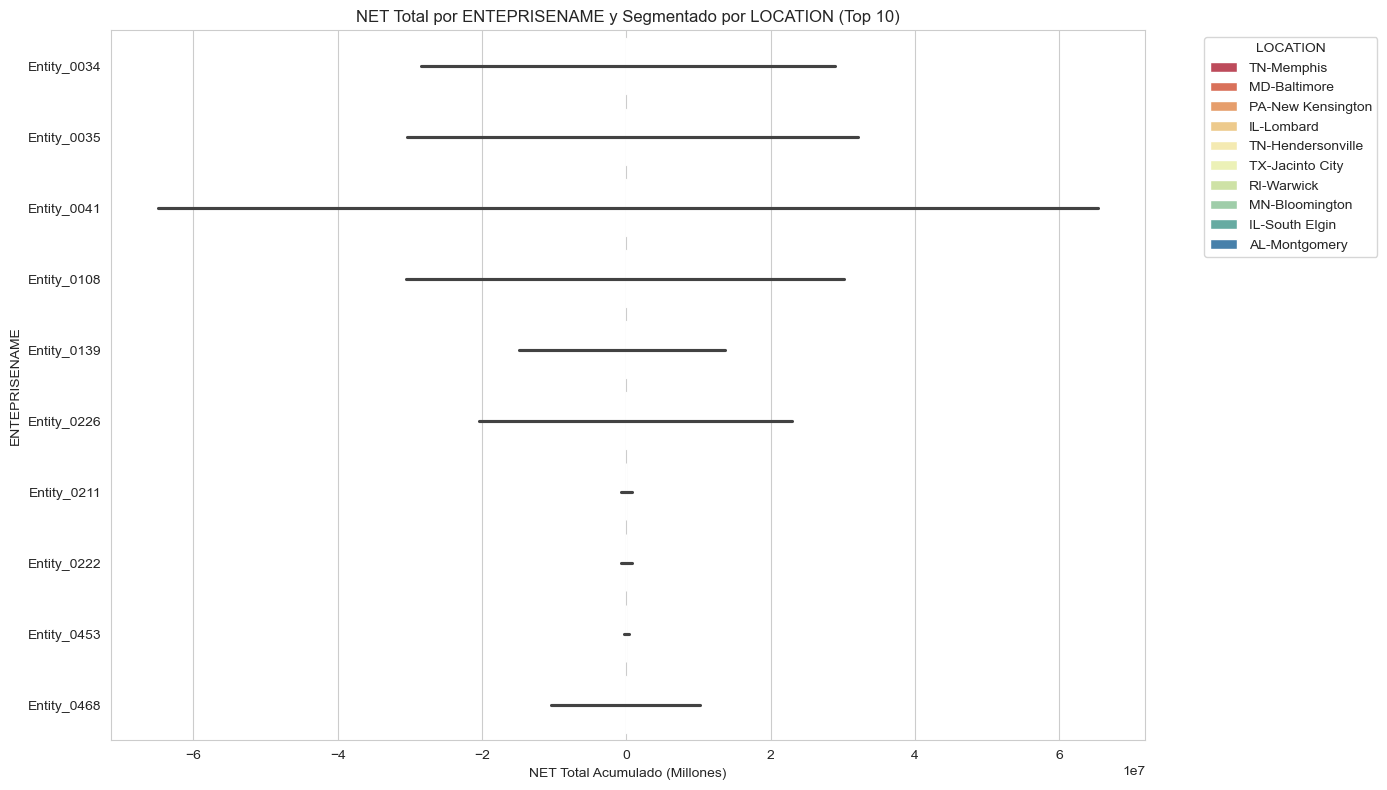


✅ Gráfico de segmentación generado. Permite ver qué ubicaciones impulsan el rendimiento en cada entidad.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 
# Usando la ruta actualizada por el usuario
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'

def clean_column_names(df):
    """Limpia los nombres de columna quitando espacios en blanco (leading/trailing)."""
    df.columns = df.columns.str.strip()
    return df

def perform_segmentation_analysis(df, segment_col_1='ENTEPRISENAME', segment_col_2='LOCATION'):
    """
    Recomendación 4.3. Segmentación:
    Segmenta el análisis del rendimiento financiero (NET) por las dimensiones clave.
    
    Nota: Se utiliza 'ENTEPRISENAME' (con error tipográfico) porque así aparece
    en el DataFrame cargado.
    """
    print("="*80)
    print("--- 3. ANÁLISIS DE NEGOCIO POR SEGMENTACIÓN ---")
    print("="*80)

    # 1. Agregación de datos
    required_cols = [segment_col_1, segment_col_2, 'NET']
    # Verificación de seguridad antes de agrupar
    if not all(col in df.columns for col in required_cols):
        print(f"❌ ERROR: Una o más columnas requeridas para la segmentación ({required_cols}) no se encontraron en el DataFrame.")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return pd.DataFrame()
        
    segment_data = df.groupby([segment_col_1, segment_col_2])['NET'].agg(['sum', 'mean', 'count']).reset_index()
    segment_data.rename(columns={'sum': 'NET_TOTAL', 'mean': 'NET_PROMEDIO', 'count': 'CONTEO_TRANSACCIONES'}, inplace=True)
    
    print("\n1. Top 5 Segmentos por NET Total (Rendimiento Absoluto):")
    print(segment_data.sort_values(by='NET_TOTAL', ascending=False).head(5))

    print("\n2. Top 5 Segmentos por NET Promedio (Eficiencia):")
    # Filtrar segmentos con un número mínimo de transacciones para asegurar fiabilidad
    min_transactions = segment_data['CONTEO_TRANSACCIONES'].quantile(0.75) 
    efficient_segments = segment_data[segment_data['CONTEO_TRANSACCIONES'] >= min_transactions]
    print(efficient_segments.sort_values(by='NET_PROMEDIO', ascending=False).head(5))

    # 3. Visualización: Gráfico de barras de NET TOTAL por ENTEPRISENAME
    top_enterprises = df.groupby(segment_col_1)['NET'].sum().nlargest(10).index
    df_top = df[df[segment_col_1].isin(top_enterprises)]
    
    plt.figure(figsize=(14, 8))
    # Utiliza LOCATION como color (hue) para mostrar el rendimiento segmentado
    sns.barplot(
        x='NET', 
        y=segment_col_1, 
        hue=segment_col_2, 
        data=df_top, 
        estimator=sum,
        palette='Spectral'
    )
    plt.title(f'NET Total por {segment_col_1} y Segmentado por {segment_col_2} (Top 10)')
    plt.xlabel('NET Total Acumulado (Millones)')
    plt.ylabel(segment_col_1)
    plt.legend(title=segment_col_2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show() # Muestra la imagen
    
    print("\n✅ Gráfico de segmentación generado. Permite ver qué ubicaciones impulsan el rendimiento en cada entidad.")
    
    return segment_data

if __name__ == '__main__':
    # Simulación de carga de datos para prueba
    warnings.filterwarnings('ignore') # Ignorar advertencias de copias en slice
    
    try:
        # Intenta cargar el archivo real
        df_full = pd.read_csv(FILE_PATH, encoding='latin1')
        df_full = clean_column_names(df_full) # Limpiar nombres de columnas después de cargar
        print(f"Archivo cargado. Columnas disponibles: {df_full.columns.tolist()}")

    except Exception as e:
        print(f"❌ Error al cargar el archivo ({FILE_PATH}): {type(e).__name__}: {e}. Creando datos de prueba.")
        # Crear datos de prueba si el archivo no existe
        data = {
            'ENTEPRISENAME': ['Entidad A', 'Entidad A', 'Entidad B', 'Entidad B', 'Entidad C'] * 20, # CORREGIDO aquí
            'LOCATION': ['Locación X', 'Locación Y'] * 50,
            'NET': np.random.uniform(-50000, 150000, 100),
            'YEARID': [2023] * 100,
            'MONTHID': [1] * 100
        }
        df_full = pd.DataFrame(data)
        df_full = clean_column_names(df_full) # Aplicar limpieza a los datos de prueba por si acaso.
        print(f"DataFrame de prueba creado. Columnas disponibles: {df_full.columns.tolist()}")


    # El análisis de segmentación debe ejecutarse sobre el DataFrame limpio
    perform_segmentation_analysis(df_full.copy())